In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# -----------------------------
# Data (CIFAR-10 with augmentation)
# -----------------------------
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:12<00:00, 14.1MB/s] 


In [3]:
# -----------------------------
# DenseNet (k=12, L=40)
# -----------------------------
growth_rate = 12
depth = 40
nblocks = (depth - 4) // 3   # ✅ correct = 12

drop_rate = 0.2

# -----------------------------
# Dense Layer (BN-ReLU-Conv)
# -----------------------------
class DenseLayer(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
        )

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        out = self.layer(x)
        out = self.dropout(out)
        return torch.cat([x, out], 1)

# -----------------------------
# Dense Block
# -----------------------------
def make_dense_block(in_channels, nblocks):
    layers = []
    for _ in range(nblocks):
        layers.append(DenseLayer(in_channels))
        in_channels += growth_rate
    return nn.Sequential(*layers), in_channels


# -----------------------------
# Transition Layer
# -----------------------------
class Transition(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=1, bias=False),  # no compression
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.layer(x)


# -----------------------------
# DenseNet Model
# -----------------------------
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()

        num_channels = 16

        self.conv1 = nn.Conv2d(3, num_channels, kernel_size=3, padding=1, bias=False)

        # Block 1
        self.block1, num_channels = make_dense_block(num_channels, nblocks)
        self.trans1 = Transition(num_channels)

        # Block 2
        self.block2, num_channels = make_dense_block(num_channels, nblocks)
        self.trans2 = Transition(num_channels)

        # Block 3
        self.block3, num_channels = make_dense_block(num_channels, nblocks)

        self.bn = nn.BatchNorm2d(num_channels)
        self.fc = nn.Linear(num_channels, 10)

    def forward(self, x):
        x = self.conv1(x)

        x = self.trans1(self.block1(x))
        x = self.trans2(self.block2(x))
        x = self.block3(x)

        x = torch.relu(self.bn(x))
        x = torch.nn.functional.avg_pool2d(x, 8)
        x = x.view(x.size(0), -1)

        return self.fc(x)


model = DenseNet().to(device)

In [6]:
# -----------------------------
# FLOPs + Params
# -----------------------------
from thop import profile, clever_format

dummy = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy,), verbose=False)
flops, params = clever_format([flops, params], "%.3f")

print("FLOPs:", flops)
print("Params:", params)

FLOPs: 273.899M
Params: 1.020M


In [8]:
# -----------------------------
# Gradient Hooks (CLEAN & CORRECT)
# -----------------------------
gradients = {}
grad_history = []
layer_names = []

def hook_fn(name):
    def hook(module, grad_input, grad_output):
        if grad_output[0] is not None:
            gradients[name] = grad_output[0].abs().mean().item()
    return hook

# Register hooks ONCE and keep order
for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        layer_names.append(name)
        layer.register_full_backward_hook(hook_fn(name))

In [9]:
# -----------------------------
# Training Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[50, 75],
    gamma=0.1
)

num_epochs = 100

history = {
    "Epoch": [],
    "Train Acc": [],
    "Test Acc Top1": [],
    "Test Acc Top5": [],
    "Train Loss": [],
    "Test Loss": [],
    "Precision": [],
    "Recall": []
}

# -----------------------------
# Evaluation Function
# -----------------------------
from sklearn.metrics import precision_score, recall_score

def evaluate(loader):
    model.eval()
    total_loss, correct1, correct5, total = 0, 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item()

            # Top-1
            _, pred1 = out.max(1)
            correct1 += pred1.eq(y).sum().item()

            # Top-5 (vectorized)
            pred5 = out.topk(5, dim=1)[1]
            correct5 += pred5.eq(y.view(-1, 1)).sum().item()

            total += y.size(0)

            all_preds.extend(pred1.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    acc1 = 100 * correct1 / total
    acc5 = 100 * correct5 / total
    avg_loss = total_loss / len(loader)

    precision = precision_score(all_targets, all_preds, average='macro')
    recall = recall_score(all_targets, all_preds, average='macro')

    return avg_loss, acc1, acc5, precision, recall


# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    gradients.clear()  # IMPORTANT

    for i, (x, y) in enumerate(trainloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        # Capture gradients (first batch per epoch)
        if i == 0:
            grad_history.append([gradients.get(name, 0) for name in layer_names])

        optimizer.step()

        running_loss += loss.item()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    test_loss, test_acc1, test_acc5, precision, recall = evaluate(testloader)

    scheduler.step()

    # Store history
    history["Epoch"].append(epoch + 1)
    history["Train Acc"].append(train_acc)
    history["Test Acc Top1"].append(test_acc1)
    history["Test Acc Top5"].append(test_acc5)
    history["Train Loss"].append(train_loss)
    history["Test Loss"].append(test_loss)
    history["Precision"].append(precision)
    history["Recall"].append(recall)

    print(f"Epoch {epoch+1}: "
          f"Train Acc {train_acc:.2f}% | Test Acc {test_acc1:.2f}% | "
          f"Train Loss {train_loss:.4f} | Test Loss {test_loss:.4f}")

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 1: Train Acc 45.01% | Test Acc 52.82% | Train Loss 1.4940 | Test Loss 1.3961


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 2: Train Acc 62.76% | Test Acc 59.90% | Train Loss 1.0405 | Test Loss 1.3621


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


...

Epoch 98: Train Acc 98.60% | Test Acc 93.34% | Train Loss 0.0434 | Test Loss 0.2662


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 99: Train Acc 98.58% | Test Acc 93.37% | Train Loss 0.0434 | Test Loss 0.2596


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 100: Train Acc 98.60% | Test Acc 93.30% | Train Loss 0.0427 | Test Loss 0.2656


In [11]:
# -----------------------------
# Save Model
# -----------------------------
torch.save(model.state_dict(), "densenet_cifar10.pth")

# -----------------------------
# Save Excel
# -----------------------------
df = pd.DataFrame(history)
df["FLOPs"] = flops
df["Params"] = params
df.to_excel("densenet_results.xlsx", index=False)


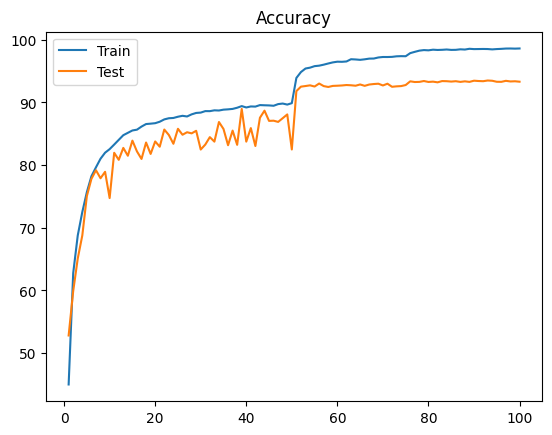

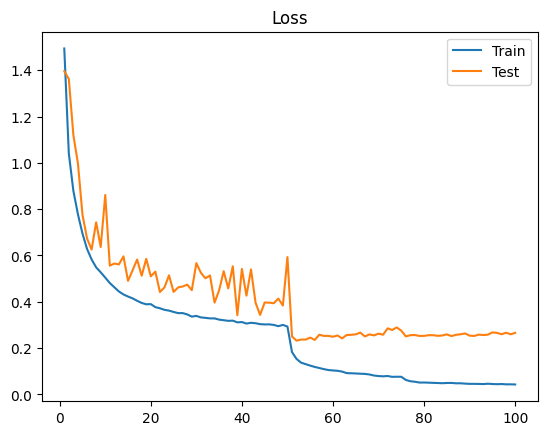

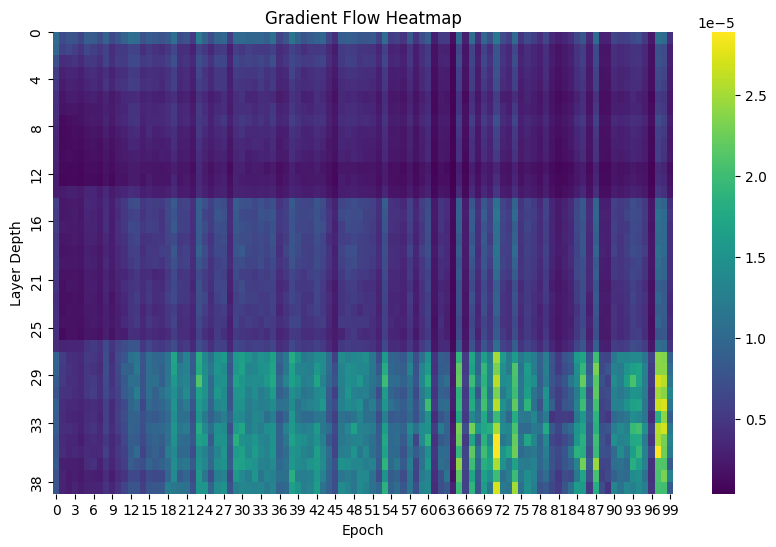

In [15]:
# -----------------------------
# Plots
# -----------------------------
plt.plot(history["Epoch"], history["Train Acc"], label="Train")
plt.plot(history["Epoch"], history["Test Acc Top1"], label="Test")
plt.legend(); plt.title("Accuracy"); plt.show()

plt.plot(history["Epoch"], history["Train Loss"], label="Train")
plt.plot(history["Epoch"], history["Test Loss"], label="Test")
plt.legend(); plt.title("Loss"); plt.show()

# -----------------------------
# Gradient Heatmap
# -----------------------------
num_layers = grad_matrix.shape[0]

# pick ~10 evenly spaced layers
ticks = np.linspace(0, num_layers - 1, 10, dtype=int)

plt.figure(figsize=(10, 6))
sns.heatmap(grad_matrix, cmap="viridis")

plt.yticks(ticks, ticks)   # show selected layer indices
plt.xlabel("Epoch")
plt.ylabel("Layer Depth")
plt.title("Gradient Flow Heatmap")

plt.show()

In [13]:
# -----------------------------
# Final Evaluation
# -----------------------------
final_loss, final_acc1, final_acc5, precision, recall = evaluate(testloader)

print("\nFinal Results:")
print(f"Top-1: {final_acc1:.2f}%")
print(f"Top-5: {final_acc5:.2f}%")
print(f"Loss: {final_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Error: {100-final_acc1:.2f}%")


Final Results:
Top-1: 93.30%
Top-5: 99.88%
Loss: 0.2656
Precision: 0.9336
Recall: 0.9330
Error: 6.70%
